# Rerank cutoff 02 — Hard global score threshold

**Scope:** rerank-only analysis. Gold is evaluated only within the top-N
candidate pool `C_q^N` (not full retrieval recall).

For each reranker family (`bgem3`, `bge_gemma`), sweep a global score threshold
`t` and measure **conditional residual recall loss** on pool-reachable gold
`G_q^(N) = G_q ∩ C_q^N`:

`residual_loss_q(t) = |G_q^(N) \\ K_q(t)| / |G_q^(N)|`, with `K_q(t) = {d in C_q^N : score(d) >= t}`.

Select the **largest** `t` such that macro mean loss `<= alpha` and p90 loss `<= beta`
(defaults `alpha=0.10`, `beta=0.30`). See **Discussion** for caveats.

In [1]:
from __future__ import annotations

import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore[assignment]

try:
    _NB_DIR = Path(__file__).resolve().parent
except NameError:
    _NB_DIR = Path(".").resolve()
    if not (_NB_DIR / "scripts").exists():
        _NB_DIR = _NB_DIR.parent

REPO_ROOT = _NB_DIR if (_NB_DIR / "scripts").exists() else _NB_DIR.parent
assert (REPO_ROOT / "scripts").exists(), f"Cannot locate repo root (tried {REPO_ROOT})"
sys.path.insert(0, str(REPO_ROOT / "scripts" / "public" / "shared_scripts"))
sys.path.insert(0, str(REPO_ROOT / "notebooks"))

from retrieval_eval.common import build_topics_and_gold, load_questions

from _rerank_plot_sample import DEFAULT_N_GOLD_BINS, sample_queries_for_diagnostic_plots

## Configuration

In [2]:
N_CAP = 200
ALPHA_DEFAULT = 0.10
BETA_DEFAULT = 0.30
ALPHA_GRID = [0.05, 0.10, 0.15]
BETA_GRID = [0.20, 0.30, 0.40]

RNG_SEED = 42
SAMPLE_SIZE = 48
MAX_UNIQUE_T = 8000

RERANK_RUN_SOURCES: list[tuple[str, Path]] = [
    (
        "bgem3",
        REPO_ROOT / "output" / "workflow_baseline_full_run_both_routes" / "rerank" / "runs",
    ),
    (
        "bge_gemma",
        REPO_ROOT / "output" / "workflow_baseline_full_run_both_routes_gemma" / "rerank" / "runs",
    ),
]

GOLD_JSON_MAP: dict[str, Path] = {
    "13B1_golden": REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B1_golden.json",
    "13B2_golden": REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B2_golden.json",
    "13B3_golden": REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B3_golden.json",
    "13B4_golden": REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B4_golden.json",
    "training14b_10pct_sample": REPO_ROOT / "example" / "training14b_10pct_sample.json",
}

## Helpers

In [3]:
def load_run_tsv(path: Path, n_cap: int = 200) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    df["score"] = df["score"].astype(float)
    df["docno"] = df["docno"].astype(str)
    df = df.sort_values(["qid", "score"], ascending=[True, False])
    return df.groupby("qid").head(n_cap).reset_index(drop=True)


def load_gold_set_map(json_path: Path) -> dict[str, set[str]]:
    qs = load_questions(json_path)
    _, gold_lists = build_topics_and_gold(qs)
    return {qid: set(pmids) for qid, pmids in gold_lists.items()}


def _split_from_stem(stem: str) -> str | None:
    m = re.match(r"best_rrf_(.+?)_top\d+", stem)
    return m.group(1) if m else None


def build_t_candidates(all_scores: list[np.ndarray], max_unique: int = MAX_UNIQUE_T) -> np.ndarray:
    if not all_scores:
        return np.array([0.0])
    u = np.unique(np.concatenate([np.asarray(s, dtype=np.float64) for s in all_scores]))
    u.sort()
    if len(u) > max_unique:
        idx = np.round(np.linspace(0, len(u) - 1, max_unique)).astype(int)
        u = np.unique(u[idx])
    t0 = float(u[0] - 1e-12) if len(u) else 0.0
    return np.concatenate([[t0], u])


def sweep_thresholds_for_source(
    queries: list[dict],
) -> tuple[pd.DataFrame, dict]:
    """*queries*: each dict has scores (np desc), gold_mask (bool), R (int >0)."""
    if not queries:
        return pd.DataFrame(), dict(n_queries=0)
    all_scores = [q["scores"] for q in queries]
    t_candidates = build_t_candidates(all_scores)
    rows = []
    for t in t_candidates:
        losses = []
        kepts = []
        for q in queries:
            sc = q["scores"]
            gm = q["gold_mask"]
            R = int(gm.sum())
            lost = int(np.sum((sc < t) & gm))
            losses.append(lost / R)
            kepts.append(int(np.sum(sc >= t)))
        lo = np.asarray(losses, dtype=np.float64)
        rows.append(
            dict(
                t=float(t),
                macro_mean_loss=float(lo.mean()),
                macro_median_loss=float(np.median(lo)),
                p90_loss=float(np.percentile(lo, 90)),
                mean_kept=float(np.mean(kepts)),
                median_kept=float(np.median(kepts)),
                n_queries=len(queries),
            )
        )
    sweep = pd.DataFrame(rows)
    meta = dict(n_queries=len(queries))
    return sweep, meta


def select_t_star(sweep: pd.DataFrame, alpha: float, beta: float) -> float | None:
    ok = (sweep["macro_mean_loss"] <= alpha) & (sweep["p90_loss"] <= beta)
    idx = np.where(ok.values)[0]
    if len(idx) == 0:
        return None
    return float(sweep["t"].values[idx[-1]])

## 1. Load runs and per-query pool statistics

In [4]:
meta_rows: list[dict] = []
query_by_key: dict[tuple[str, str, str], dict] = {}

for src, runs_dir in RERANK_RUN_SOURCES:
    if not runs_dir.is_dir():
        print(f"[skip] {src}: missing {runs_dir}")
        continue
    for rp in sorted(runs_dir.glob("best_rrf_*_top*.tsv")):
        split = _split_from_stem(rp.stem)
        if split is None or split not in GOLD_JSON_MAP:
            continue
        gp = GOLD_JSON_MAP[split]
        if not gp.exists():
            continue
        rdf = load_run_tsv(rp, N_CAP)
        gmap = load_gold_set_map(gp)
        common = sorted(set(rdf["qid"].unique()) & set(gmap))
        for qid in common:
            qdf = rdf[rdf["qid"] == qid]
            scores = qdf["score"].values.astype(np.float64)
            docnos = qdf["docno"].values.astype(str)
            gold = gmap[qid]
            pool = set(docnos)
            gold_in_pool = gold & pool
            R = len(gold_in_pool)
            gold_mask = np.array([d in gold_in_pool for d in docnos], dtype=bool)
            meta_rows.append(
                dict(
                    rerank_source=src,
                    split=split,
                    qid=qid,
                    n_gold_full=len(gold),
                    n_pool_gold=R,
                    n_docs=len(scores),
                )
            )
            query_by_key[(src, split, qid)] = dict(
                scores=scores,
                docnos=docnos,
                gold_mask=gold_mask,
                gold_in_pool=gold_in_pool,
                R=R,
            )

df_meta = pd.DataFrame(meta_rows)
print(df_meta.groupby("rerank_source").size())
print("skipped no pool gold (per row):", int((df_meta["n_pool_gold"] == 0).sum()))

rerank_source
bge_gemma    923
bgem3        923
dtype: int64
skipped no pool gold (per row): 92


## 2. Threshold sweep and default selection (per rerank_source, pooled splits)

In [5]:
sweep_by_src: dict[str, pd.DataFrame] = {}
t_star_by_src: dict[str, float | None] = {}
skip_report: list[dict] = []

for src in [s for s, _ in RERANK_RUN_SOURCES]:
    keys = [k for k in query_by_key if k[0] == src]
    queries = [query_by_key[k] for k in keys if query_by_key[k]["R"] > 0]
    n_skip = sum(1 for k in keys if query_by_key[k]["R"] == 0)
    skip_report.append(dict(rerank_source=src, n_queries_R_pos=len(queries), n_queries_R_zero=n_skip))
    if not queries:
        print(f"{src}: no queries with pool gold; skip sweep")
        continue
    sw, _ = sweep_thresholds_for_source(queries)
    sweep_by_src[src] = sw
    t_star_by_src[src] = select_t_star(sw, ALPHA_DEFAULT, BETA_DEFAULT)
    print(f"{src}: selected t* = {t_star_by_src[src]}  (alpha={ALPHA_DEFAULT}, beta={BETA_DEFAULT})")

df_skip = pd.DataFrame(skip_report)
display(df_skip)

bgem3: selected t* = 0.5120109915733337  (alpha=0.1, beta=0.3)
bge_gemma: selected t* = 6.8125  (alpha=0.1, beta=0.3)


,rerank_source,n_queries_R_pos,n_queries_R_zero
0,bgem3,874,49
1,bge_gemma,880,43


## 1b. Aligned pool-conditional summary at `t*` (trilogy table schema)

In [6]:
def _metrics_at_t(
    queries: list[tuple[tuple[str, str, str], dict]], t: float | None,
) -> dict:
    if t is None or not queries:
        return dict(
            n_eval=0,
            n_skipped_pool_gold=0,
            mean_res_loss=np.nan,
            median_res_loss=np.nan,
            p90_res_loss=np.nan,
            mean_kept=np.nan,
            median_kept=np.nan,
        )
    losses, kepts = [], []
    for _k, q in queries:
        sc, gm = q["scores"], q["gold_mask"]
        R = int(gm.sum())
        if R == 0:
            continue
        losses.append(float(np.sum((sc < t) & gm) / R))
        kepts.append(int(np.sum(sc >= t)))
    if not losses:
        return dict(
            n_eval=0,
            n_skipped_pool_gold=0,
            mean_res_loss=np.nan,
            median_res_loss=np.nan,
            p90_res_loss=np.nan,
            mean_kept=np.nan,
            median_kept=np.nan,
        )
    lo = np.asarray(losses, dtype=np.float64)
    kk = np.asarray(kepts, dtype=np.float64)
    return dict(
        n_eval=len(losses),
        n_skipped_pool_gold=0,
        mean_res_loss=float(lo.mean()),
        median_res_loss=float(np.median(lo)),
        p90_res_loss=float(np.percentile(lo, 90)),
        mean_kept=float(kk.mean()),
        median_kept=float(np.median(kk)),
    )


_align_fmt = dict(
    mean_res_loss="{:.4f}",
    median_res_loss="{:.4f}",
    p90_res_loss="{:.4f}",
    mean_kept="{:.1f}",
    median_kept="{:.0f}",
)

for src in [s for s, _ in RERANK_RUN_SOURCES]:
    t_star = t_star_by_src.get(src)
    align_rows = []
    for split in sorted(df_meta[df_meta["rerank_source"] == src]["split"].unique()):
        keys = [k for k in query_by_key if k[0] == src and k[1] == split]
        all_k = [(k, query_by_key[k]) for k in keys]
        n_sk = sum(1 for k, q in all_k if q["R"] == 0)
        qpos = [(k, q) for k, q in all_k if q["R"] > 0]
        m = _metrics_at_t(qpos, t_star)
        m["n_skipped_pool_gold"] = n_sk
        align_rows.append(
            dict(
                rerank_source=src,
                split=split,
                method="hard_t_star",
                t_star=t_star,
                **m,
            )
        )
    # pooled
    keys = [k for k in query_by_key if k[0] == src]
    all_k = [(k, query_by_key[k]) for k in keys]
    n_sk = sum(1 for k, q in all_k if q["R"] == 0)
    qpos = [(k, q) for k, q in all_k if q["R"] > 0]
    m = _metrics_at_t(qpos, t_star)
    m["n_skipped_pool_gold"] = n_sk
    align_rows.append(
        dict(
            rerank_source=src,
            split="__pooled__",
            method="hard_t_star",
            t_star=t_star,
            **m,
        )
    )
    print(f"\n=== Aligned at t*  ({src}) ===")
    display(pd.DataFrame(align_rows).style.format(_align_fmt))


=== Aligned at t*  (bgem3) ===


,rerank_source,split,method,t_star,n_eval,n_skipped_pool_gold,mean_res_loss,median_res_loss,p90_res_loss,mean_kept,median_kept
0,bgem3,13B1_golden,hard_t_star,0.512011,84,1,0.0522,0.0000,0.1245,137.0,200
1,bgem3,13B2_golden,hard_t_star,0.512011,85,0,0.0732,0.0000,0.2857,125.1,200
2,bgem3,13B3_golden,hard_t_star,0.512011,85,0,0.0569,0.0000,0.2185,137.3,200
3,bgem3,13B4_golden,hard_t_star,0.512011,84,1,0.0563,0.0000,0.0876,169.8,200
4,bgem3,training14b_10pct_sample,hard_t_star,0.512011,536,47,0.0853,0.0000,0.3333,124.4,149
5,bgem3,__pooled__,hard_t_star,0.512011,874,49,0.0754,0.0000,0.3000,131.3,182



=== Aligned at t*  (bge_gemma) ===


,rerank_source,split,method,t_star,n_eval,n_skipped_pool_gold,mean_res_loss,median_res_loss,p90_res_loss,mean_kept,median_kept
0,bge_gemma,13B1_golden,hard_t_star,6.812500,85,0,0.0521,0.0000,0.1302,123.8,130
1,bge_gemma,13B2_golden,hard_t_star,6.812500,85,0,0.0751,0.0000,0.2004,107.9,104
2,bge_gemma,13B3_golden,hard_t_star,6.812500,85,0,0.0840,0.0000,0.3053,120.1,134
3,bge_gemma,13B4_golden,hard_t_star,6.812500,85,0,0.1067,0.0000,0.4798,141.8,191
4,bge_gemma,training14b_10pct_sample,hard_t_star,6.812500,540,43,0.0737,0.0000,0.2857,110.4,102
5,bge_gemma,__pooled__,hard_t_star,6.812500,880,43,0.0760,0.0000,0.2879,115.4,111


### Sweep summary (decimated for display if long)

In [7]:
_disp_n = 400
for src, sw in sweep_by_src.items():
    print(f"\n=== {src}  (showing up to {_disp_n} rows) ===")
    sub = sw if len(sw) <= _disp_n else sw.iloc[:: max(1, len(sw) // _disp_n)]
    display(sub.style.format({c: "{:.4f}" for c in sub.columns if c != "n_queries"}))


=== bgem3  (showing up to 400 rows) ===


,t,macro_mean_loss,macro_median_loss,p90_loss,mean_kept,median_kept,n_queries
0,0.0000,0.0000,0.0000,0.0000,200.0000,200.0000,874
20,0.0008,0.0000,0.0000,0.0000,199.5366,200.0000,874
40,0.0012,0.0000,0.0000,0.0000,199.0389,200.0000,874
60,0.0015,0.0000,0.0000,0.0000,198.5492,200.0000,874
80,0.0020,0.0000,0.0000,0.0000,198.0538,200.0000,874
100,0.0025,0.0000,0.0000,0.0000,197.5526,200.0000,874
120,0.0032,0.0000,0.0000,0.0000,197.0526,200.0000,874
140,0.0040,0.0000,0.0000,0.0000,196.5572,200.0000,874
160,0.0048,0.0000,0.0000,0.0000,196.0664,200.0000,874
180,0.0057,0.0000,0.0000,0.0000,195.5686,200.0000,874



=== bge_gemma  (showing up to 400 rows) ===


,t,macro_mean_loss,macro_median_loss,p90_loss,mean_kept,median_kept,n_queries
0,-2.7793,0.0000,0.0000,0.0000,200.0000,200.0000,880
15,-2.6934,0.0000,0.0000,0.0000,199.9739,200.0000,880
30,-2.5957,0.0000,0.0000,0.0000,199.9511,200.0000,880
45,-2.5137,0.0000,0.0000,0.0000,199.9205,200.0000,880
60,-2.3945,0.0000,0.0000,0.0000,199.8977,200.0000,880
75,-2.2207,0.0000,0.0000,0.0000,199.8739,200.0000,880
90,-1.9854,0.0000,0.0000,0.0000,199.8511,200.0000,880
105,-1.7197,0.0000,0.0000,0.0000,199.8307,200.0000,880
120,-1.5381,0.0000,0.0000,0.0000,199.8091,200.0000,880
135,-1.3945,0.0000,0.0000,0.0000,199.7886,200.0000,880


## 3. Aggregate plots and selected threshold

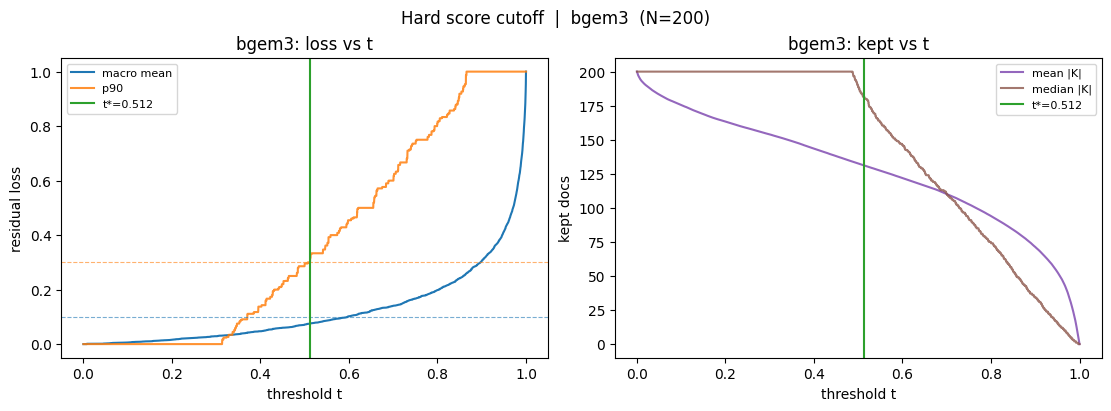

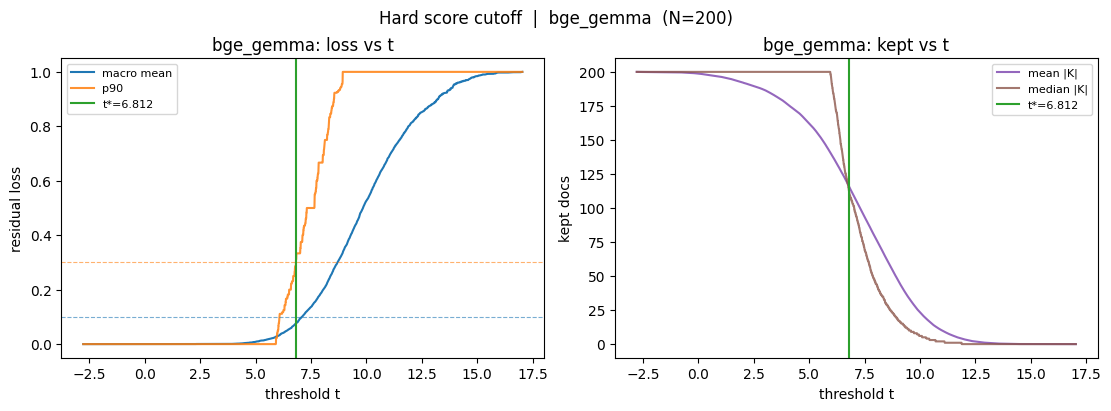

In [8]:
for src, sw in sweep_by_src.items():
    t_star = t_star_by_src.get(src)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

    ax = axes[0]
    ax.plot(sw["t"], sw["macro_mean_loss"], label="macro mean", color="tab:blue")
    ax.plot(sw["t"], sw["p90_loss"], label="p90", color="tab:orange", alpha=0.85)
    ax.axhline(ALPHA_DEFAULT, color="tab:blue", ls="--", lw=0.8, alpha=0.6)
    ax.axhline(BETA_DEFAULT, color="tab:orange", ls="--", lw=0.8, alpha=0.6)
    if t_star is not None:
        ax.axvline(t_star, color="tab:green", lw=1.5, label=f"t*={t_star:.4g}")
    ax.set_xlabel("threshold t")
    ax.set_ylabel("residual loss")
    ax.legend(loc="best", fontsize=8)
    ax.set_title(f"{src}: loss vs t")

    ax2 = axes[1]
    ax2.plot(sw["t"], sw["mean_kept"], label="mean |K|", color="tab:purple")
    ax2.plot(sw["t"], sw["median_kept"], label="median |K|", color="tab:brown", alpha=0.8)
    if t_star is not None:
        ax2.axvline(t_star, color="tab:green", lw=1.5, label=f"t*={t_star:.4g}")
    ax2.set_xlabel("threshold t")
    ax2.set_ylabel("kept docs")
    ax2.legend(loc="best", fontsize=8)
    ax2.set_title(f"{src}: kept vs t")

    fig.suptitle(f"Hard score cutoff  |  {src}  (N={N_CAP})", fontsize=12)
    plt.show()

## 4. Alpha / beta sensitivity

In [9]:
def sensitivity_table(sweep: pd.DataFrame, src: str) -> pd.DataFrame:
    rows = []
    for a in ALPHA_GRID:
        t_ = select_t_star(sweep, a, BETA_DEFAULT)
        row: dict = dict(rerank_source=src, mode="vary_alpha", alpha=a, beta=BETA_DEFAULT, t_star=t_)
        if t_ is not None:
            m = sweep[np.isclose(sweep["t"], t_, rtol=0.0, atol=1e-9)]
            if m.empty:
                m = sweep.iloc[(sweep["t"] - t_).abs().argsort()[:1]]
            row["macro_mean_at_t"] = float(m["macro_mean_loss"].iloc[0])
            row["p90_at_t"] = float(m["p90_loss"].iloc[0])
            row["mean_kept_at_t"] = float(m["mean_kept"].iloc[0])
        rows.append(row)
    for b in BETA_GRID:
        t_ = select_t_star(sweep, ALPHA_DEFAULT, b)
        row = dict(rerank_source=src, mode="vary_beta", alpha=ALPHA_DEFAULT, beta=b, t_star=t_)
        if t_ is not None:
            m = sweep[np.isclose(sweep["t"], t_, rtol=0.0, atol=1e-9)]
            if m.empty:
                m = sweep.iloc[(sweep["t"] - t_).abs().argsort()[:1]]
            row["macro_mean_at_t"] = float(m["macro_mean_loss"].iloc[0])
            row["p90_at_t"] = float(m["p90_loss"].iloc[0])
            row["mean_kept_at_t"] = float(m["mean_kept"].iloc[0])
        rows.append(row)
    return pd.DataFrame(rows)


for src, sw in sweep_by_src.items():
    print(f"\n=== sensitivity  {src} ===")
    display(sensitivity_table(sw, src))


=== sensitivity  bgem3 ===


,rerank_source,mode,alpha,beta,t_star,macro_mean_at_t,p90_at_t,mean_kept_at_t
0,bgem3,vary_alpha,0.05,0.3,0.411407,0.049646,0.142857,142.260870
1,bgem3,vary_alpha,0.10,0.3,0.512011,0.075430,0.300000,131.304348
2,bgem3,vary_alpha,0.15,0.3,0.512011,0.075430,0.300000,131.304348
3,bgem3,vary_beta,0.10,0.2,0.440354,0.058430,0.200000,139.074371
4,bgem3,vary_beta,0.10,0.3,0.512011,0.075430,0.300000,131.304348
5,bgem3,vary_beta,0.10,0.4,0.573464,0.093164,0.400000,124.815789



=== sensitivity  bge_gemma ===


,rerank_source,mode,alpha,beta,t_star,macro_mean_at_t,p90_at_t,mean_kept_at_t
0,bge_gemma,vary_alpha,0.05,0.3,6.414062,0.049793,0.166667,127.712500
1,bge_gemma,vary_alpha,0.10,0.3,6.812500,0.075955,0.287912,115.419318
2,bge_gemma,vary_alpha,0.15,0.3,6.812500,0.075955,0.287912,115.419318
3,bge_gemma,vary_beta,0.10,0.2,6.585938,0.058295,0.200000,122.638636
4,bge_gemma,vary_beta,0.10,0.3,6.812500,0.075955,0.287912,115.419318
5,bge_gemma,vary_beta,0.10,0.4,7.085938,0.099980,0.375000,106.631818


## 5. Canonical 48 diagnostic plots (same `(split, qid)` as notebook 01)

In [10]:
canonical_pool = (
    df_meta[df_meta["n_gold_full"] > 0][["split", "qid", "n_gold_full"]]
    .rename(columns={"n_gold_full": "n_gold"})
    .drop_duplicates(subset=["split", "qid"], keep="first")
)
canonical_48 = sample_queries_for_diagnostic_plots(
    canonical_pool,
    sample_size=SAMPLE_SIZE,
    rng_seed=RNG_SEED,
    n_gold_bins=DEFAULT_N_GOLD_BINS,
)
print(f"canonical_48: {len(canonical_48)} queries")

canonical_48: 48 queries


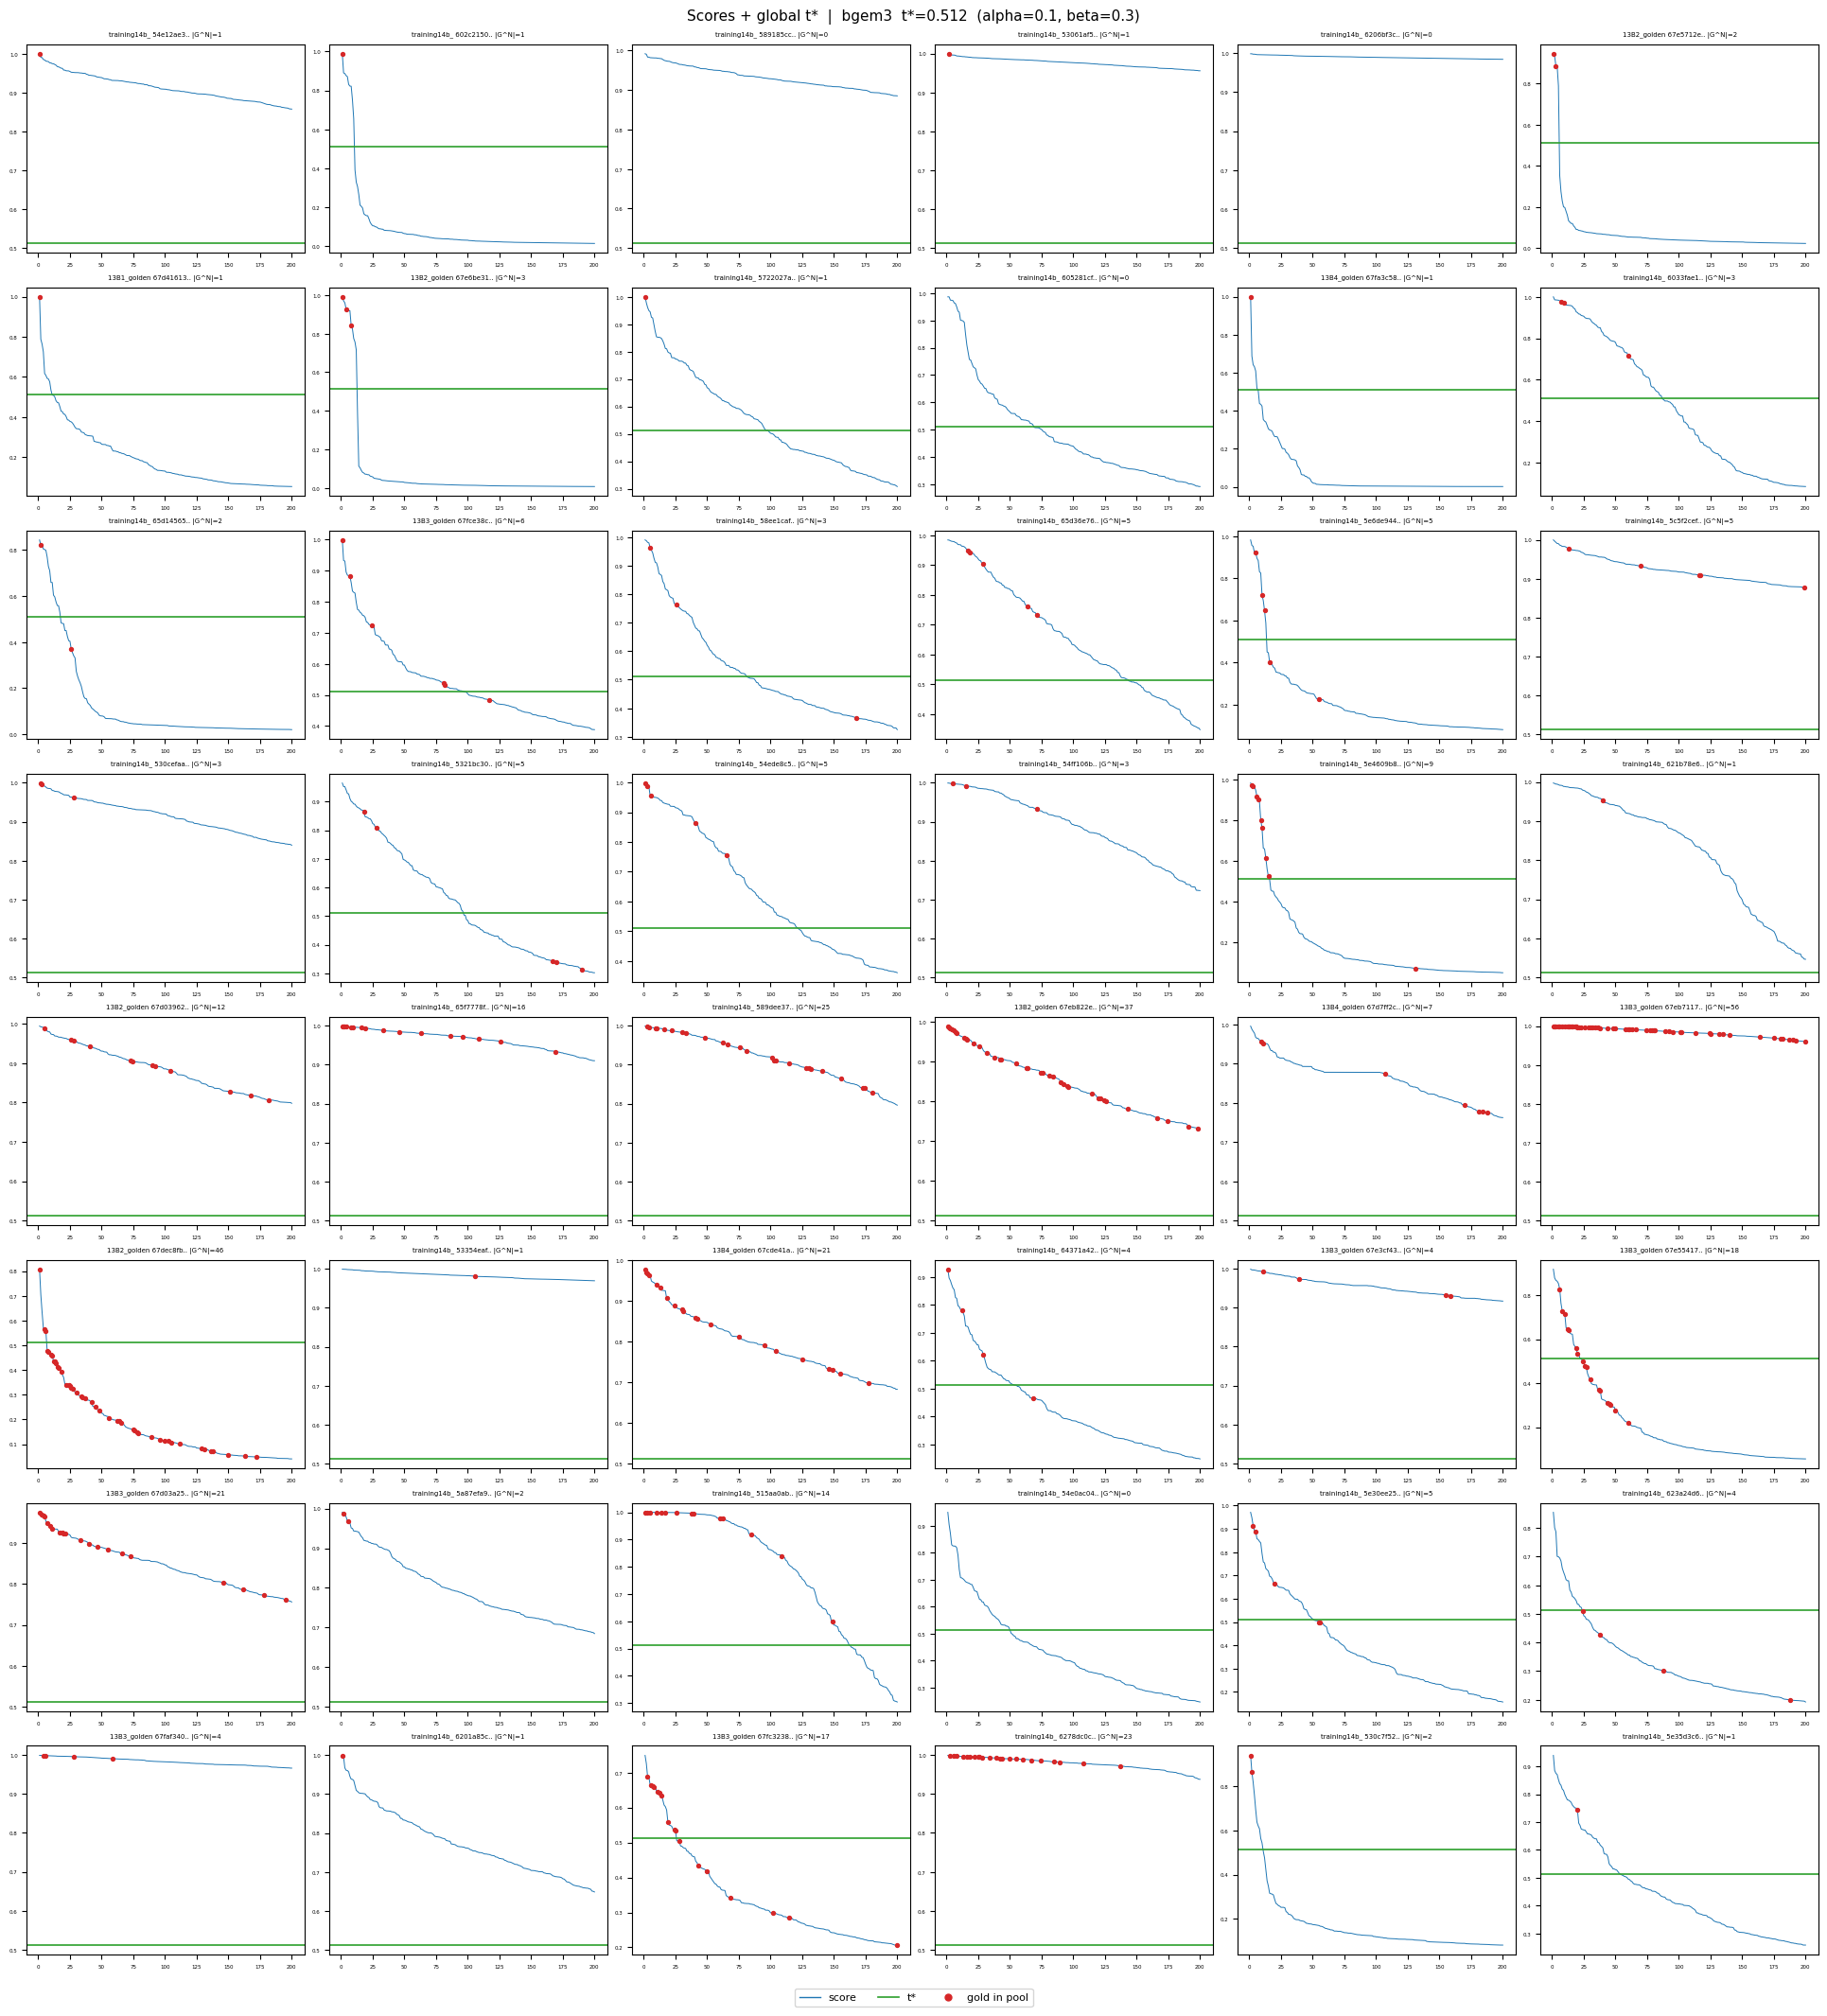

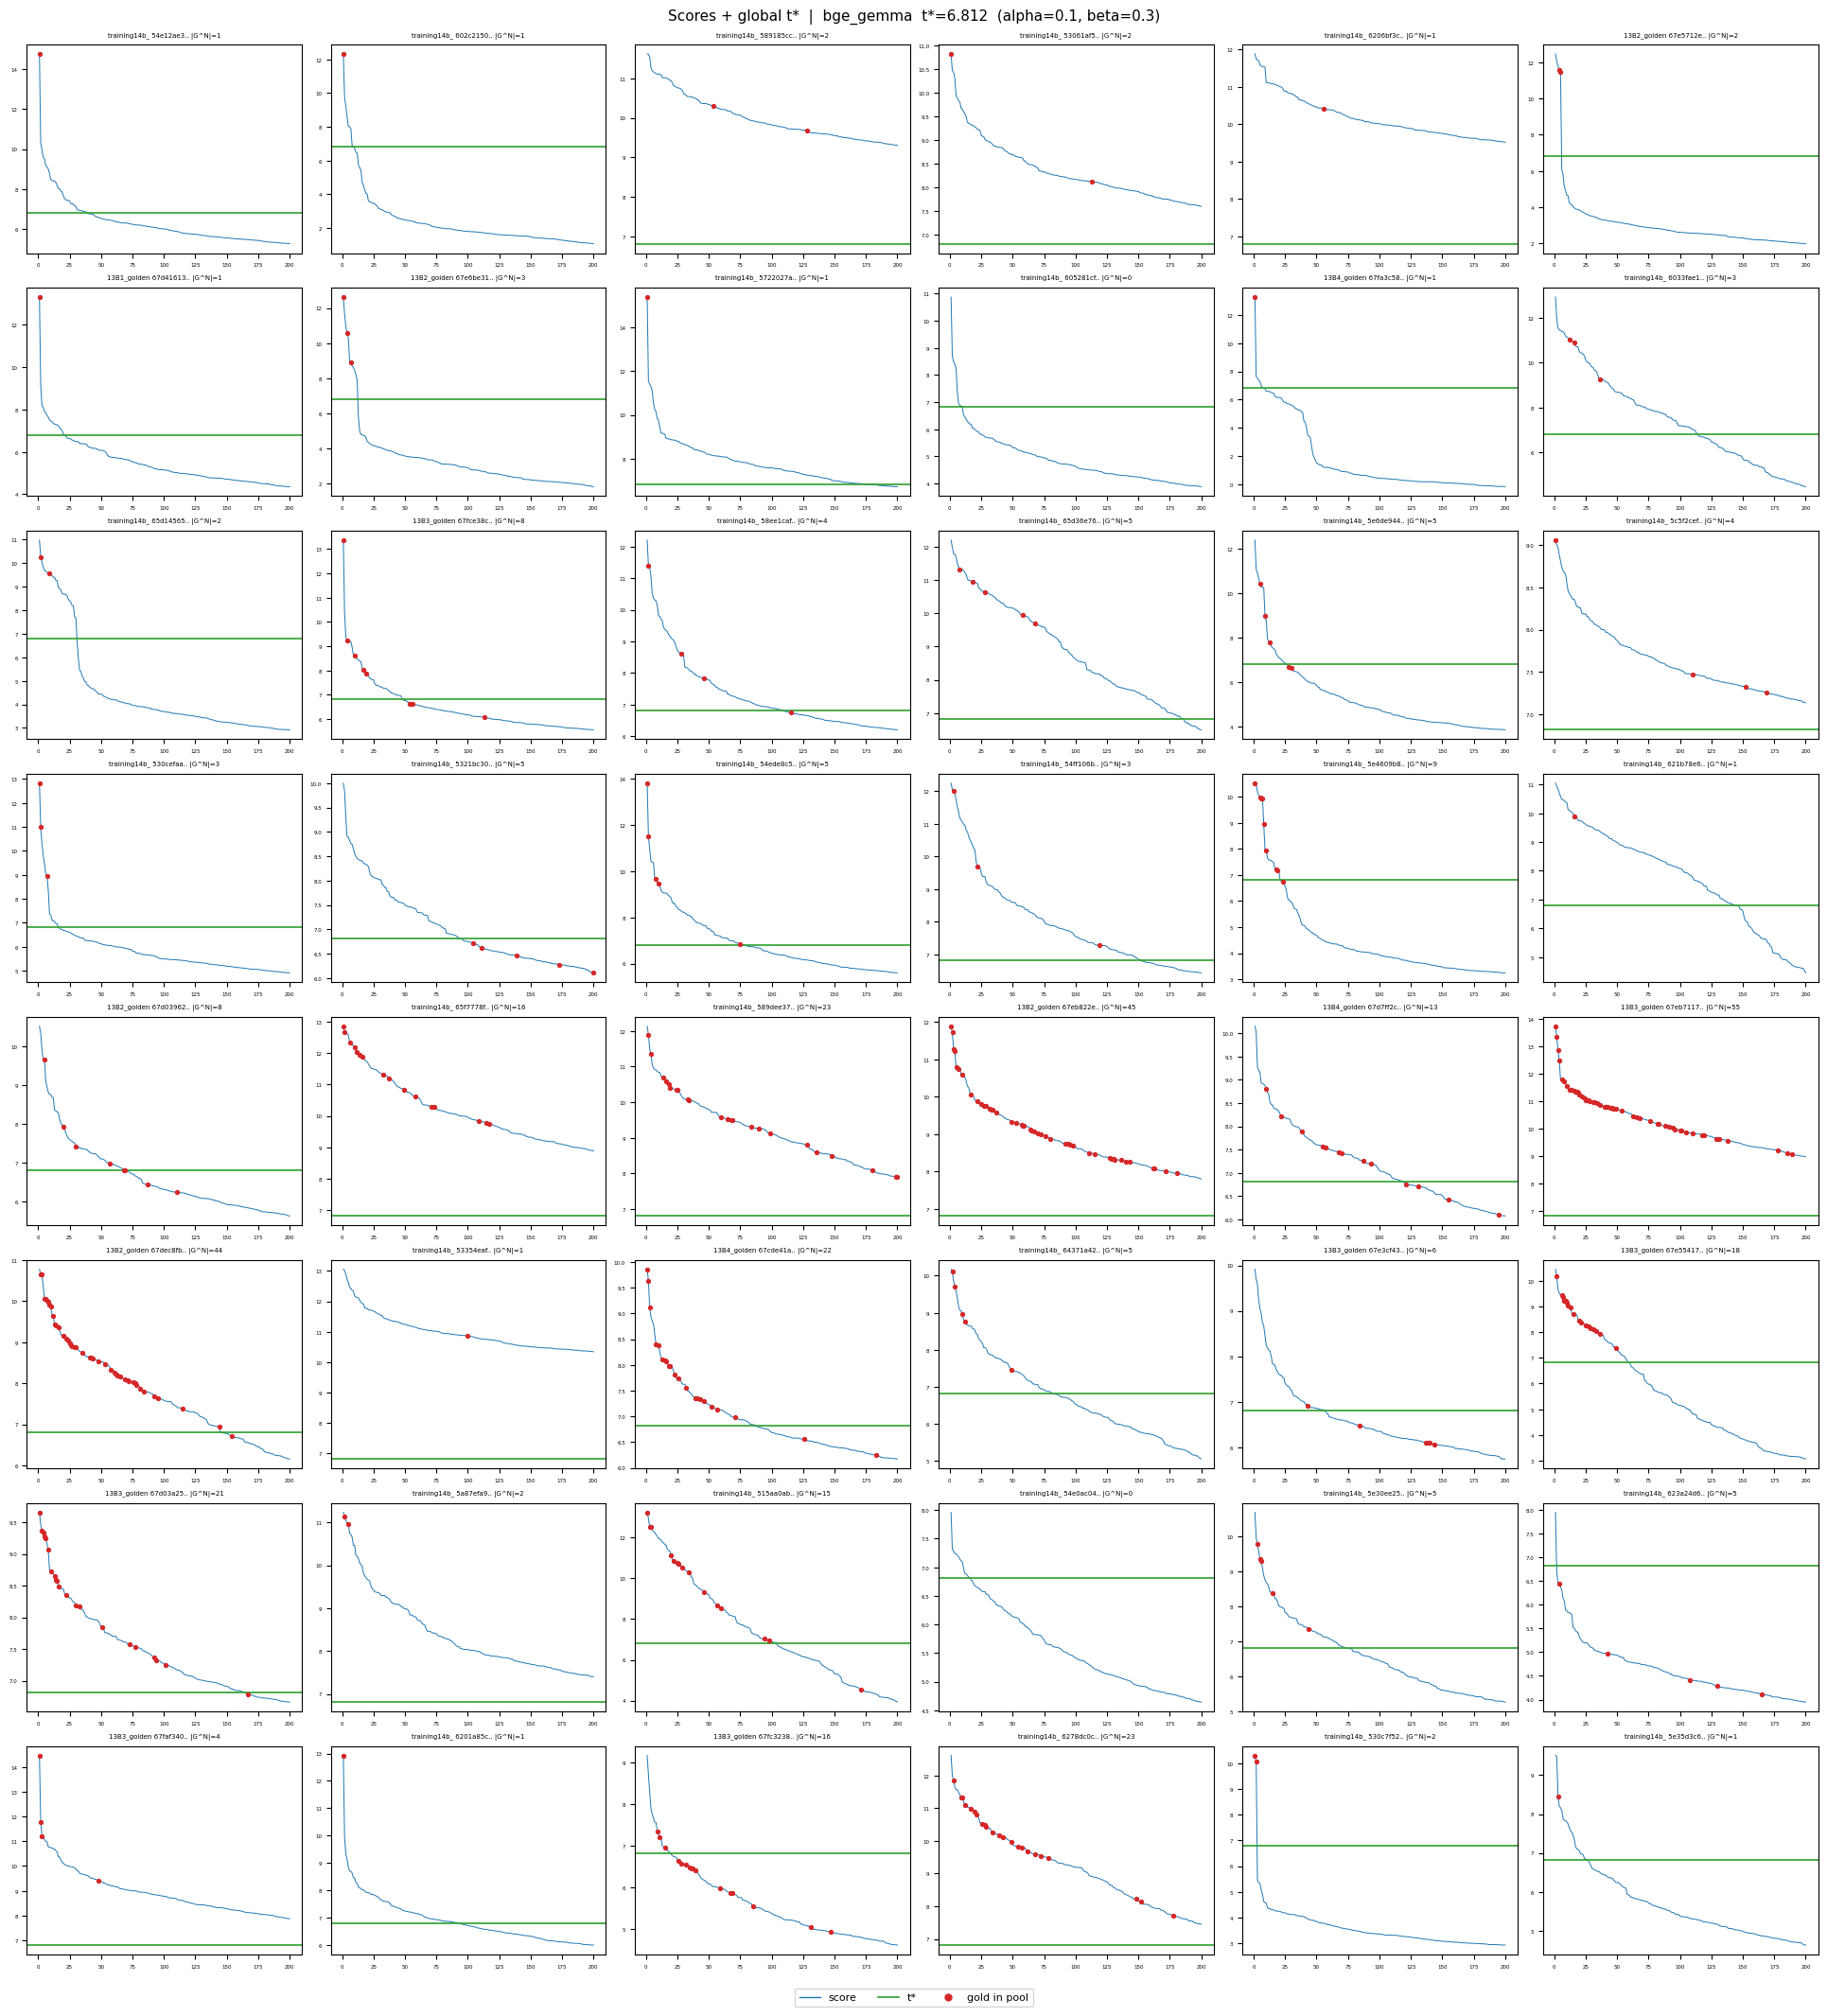

In [11]:
for src in sweep_by_src:
    t_star = t_star_by_src.get(src)
    ncols = 6
    nrows = (len(canonical_48) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.6), constrained_layout=True)
    axf = np.asarray(axes).flatten()
    for idx, (sp, qid) in enumerate(canonical_48):
        ax = axf[idx]
        key = (src, sp, qid)
        if key not in query_by_key or t_star is None:
            ax.set_visible(False)
            continue
        qd = query_by_key[key]
        sc, docnos, gm = qd["scores"], qd["docnos"], qd["gold_mask"]
        ranks = np.arange(1, len(sc) + 1)
        ax.plot(ranks, sc, color="tab:blue", lw=0.7)
        ax.axhline(t_star, color="tab:green", lw=1.2, ls="-")
        hit_ranks = ranks[gm]
        hit_scores = sc[gm]
        ax.scatter(hit_ranks, hit_scores, color="tab:red", s=8, zorder=3, label="pool gold")
        ax.set_title(f"{sp[:12]} {qid[:8]}.. |G^N|={qd['R']}", fontsize=5)
        ax.tick_params(labelsize=4)
    for j in range(len(canonical_48), len(axf)):
        axf[j].set_visible(False)
    fig.suptitle(
        f"Scores + global t*  |  {src}  t*={t_star:.4g}  (alpha={ALPHA_DEFAULT}, beta={BETA_DEFAULT})",
        fontsize=11,
    )
    h = [plt.Line2D([0], [0], color="tab:blue", lw=1, label="score"),
         plt.Line2D([0], [0], color="tab:green", lw=1.2, label="t*"),
         plt.Line2D([0], [0], marker="o", color="tab:red", ls="", markersize=5, label="gold in pool")]
    fig.legend(handles=h, loc="lower center", ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.02))
    plt.show()

## Conclusion (fill after run)

- If **loss curves** are flat near `t*`, a stable hard cutoff exists for that family.
- If curves are **sharp**, small calibration drift could violate alpha/beta.
- Compare **bgem3** vs **bge_gemma** `t*` and typical **kept** counts.

## Discussion (limitations)

1. **Small `|G_q^(N)|`**: residual loss is coarse (multiples of `1/R`); a few queries dominate macro mean.
2. **One global `t`**: ignores per-query score shift; good as a family default only.
3. **Score ties**: `|K_q(t)|` jumps at tied scores; stability depends on tie structure.
4. **p90**: at each `t`, p90 is over **per-query** residual losses (not document-level).
5. **Alpha / beta**: policy knobs; use the sensitivity tables above.
6. **Scope**: gold **outside** top-N is ignored (retrieval errors not measured).
7. **Threshold grid**: if `MAX_UNIQUE_T` subsamples unique scores, `t*` is optimal on that grid only.